# Importar o dataset

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [12]:
brute_force = pd.read_csv('datasets/02-14-2018.csv')
brute_force.columns

Index(['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts',
       'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
      

# Limpeza dos dados

In [13]:
colunas_selecionadas = [
    'Dst Port', 'Flow Duration', 'Flow Pkts/s', 'Flow Byts/s',
    'Flow IAT Mean', 'Flow IAT Std', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
    'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'RST Flag Cnt', 'FIN Flag Cnt',
    'Label'
]

df_reduzido = brute_force[colunas_selecionadas]
df_reduzido.replace([np.inf, -np.inf], np.nan, inplace=True)
df_reduzido.dropna(subset=colunas_selecionadas, inplace=True)

print(f"tamanho antes: {brute_force.shape}")
print(f"Tamanho depois: {df_reduzido.shape}")


tamanho antes: (1048575, 80)
Tamanho depois: (1044751, 13)


/var/folders/dk/tyczz1r53g1d2x4dm4p5zdsc0000gq/T/ipykernel_10229/1931613362.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reduzido.replace([np.inf, -np.inf], np.nan, inplace=True)
/var/folders/dk/tyczz1r53g1d2x4dm4p5zdsc0000gq/T/ipykernel_10229/1931613362.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reduzido.dropna(subset=colunas_selecionadas, inplace=True)


In [14]:
from sklearn.model_selection import train_test_split

X = df_reduzido.drop('Label', axis=1)
y = df_reduzido['Label']
print(y.unique())

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    train_size=0.70,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=(1/3),
    stratify=y_temp,
    random_state=42
)

print("--- DIVISÃO CONCLUÍDA ---")
print(f"Treino (70%): X={X_train.shape}, y={y_train.shape}")
print(f"Validação (20%): X={X_val.shape}, y={y_val.shape}")
print(f"Teste (10%): X={X_test.shape}, y={y_test.shape}")

['Benign' 'FTP-BruteForce' 'SSH-Bruteforce']
--- DIVISÃO CONCLUÍDA ---
Treino (70%): X=(731325, 12), y=(731325,)
Validação (20%): X=(208950, 12), y=(208950,)
Teste (10%): X=(104476, 12), y=(104476,)


In [15]:
scaler = StandardScaler()

encoder = LabelEncoder()

y_train_encoded = encoder.fit_transform(y_train)
y_val_encoded = encoder.transform(y_val)
y_test_encoded = encoder.transform(y_test)

print("Classes originais:", encoder.classes_)
print("Transformadas em:", np.unique(y_train_encoded))

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

Classes originais: ['Benign' 'FTP-BruteForce' 'SSH-Bruteforce']
Transformadas em: [0 1 2]


# Criação da rede

In [16]:
from keras import Input, layers, Model
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf

In [17]:
print("GPUs detectadas:", tf.config.list_physical_devices('GPU'))

pesos_calculados = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)
pesos_dict = dict(enumerate(pesos_calculados))
print("Pesos aplicados às classes:", pesos_dict)

def build_model(n_camadas=1, n_neuronios=32):
    N_features = X_train.shape[1]

    numero_de_classes = len(np.unique(y_train_encoded))

    x_in = Input(shape=(N_features,))
    x = x_in

    for _ in range(n_camadas):
        x = layers.Dense(n_neuronios, activation="relu")(x)

    x_out = layers.Dense(numero_de_classes, activation="softmax")(x)

    model = Model(inputs=x_in, outputs=x_out)

    model.compile(loss='sparse_categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

    return model

modelo = build_model()

GPUs detectadas: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Pesos aplicados às classes: {0: 0.5246250923961949, 1: 1.8011022959614662, 2: 1.8564539143197807}


In [18]:
report = modelo.fit(
    x=X_train,
    y=y_train_encoded,
    validation_data=(X_val, y_val_encoded),
    epochs=20,
    batch_size=512,
    class_weight=pesos_dict,
    verbose=1
)

Epoch 1/20


2026-06-30 09:54:43.296345: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1429/1429 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.5635 - loss: 0.7492 - val_accuracy: 0.7392 - val_loss: 0.4829
Epoch 2/20
1429/1429 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.7538 - loss: 0.4483 - val_accuracy: 0.8456 - val_loss: 0.4164
Epoch 3/20
1429/1429 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.8504 - loss: 0.4024 - val_accuracy: 0.8997 - val_loss: 0.3701
Epoch 4/20
1429/1429 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9132 - loss: 0.3696 - val_accuracy: 0.9297 - val_loss: 0.3328
Epoch 5/20
1429/1429 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9308 - loss: 0.3499 - val_accuracy: 0.9331 - val_loss: 0.3097
Epoch 6/20
1429/1429 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.9334 - loss: 0.3301 - val_accuracy: 0.9372 - val_loss: 0.2893
Epoch 7/20
1429/1429 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.9380 - loss: 0.3147 - val_accuracy: 0.9397 - val_loss: 0.2747
Epoch 8/20
1429/1429 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9397 - loss: 0.30

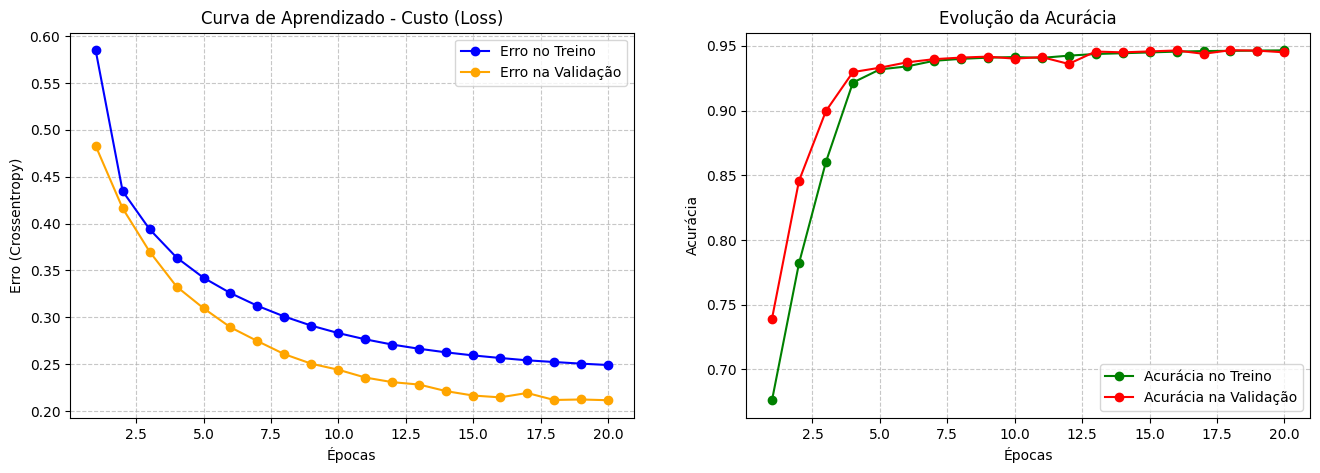

In [19]:
loss = report.history['loss']
val_loss = report.history['val_loss']
accuracy = report.history['accuracy']
val_accuracy = report.history['val_accuracy']

epochs_range = np.arange(1, len(loss) + 1)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(epochs_range, loss, label='Erro no Treino', color='blue', marker='o')
ax[0].plot(epochs_range, val_loss, label='Erro na Validação', color='orange', marker='o')
ax[0].set_title("Curva de Aprendizado - Custo (Loss)")
ax[0].set_xlabel("Épocas")
ax[0].set_ylabel("Erro (Crossentropy)")
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.7)

ax[1].plot(epochs_range, accuracy, label='Acurácia no Treino', color='green', marker='o')
ax[1].plot(epochs_range, val_accuracy, label='Acurácia na Validação', color='red', marker='o')
ax[1].set_title("Evolução da Acurácia")
ax[1].set_xlabel("Épocas")
ax[1].set_ylabel("Acurácia")
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.7)

plt.show()

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

3265/3265 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step

RELATÓRIO DE CLASSIFICAÇÃO
                precision    recall  f1-score   support

       Benigno       1.00      0.96      0.98     66381
FTP-BruteForce       1.00      0.85      0.92     19336
SSH-BruteForce       0.77      1.00      0.87     18759

      accuracy                           0.95    104476
     macro avg       0.92      0.94      0.92    104476
  weighted avg       0.96      0.95      0.95    104476


Gerando Matriz de Confusão Visual...


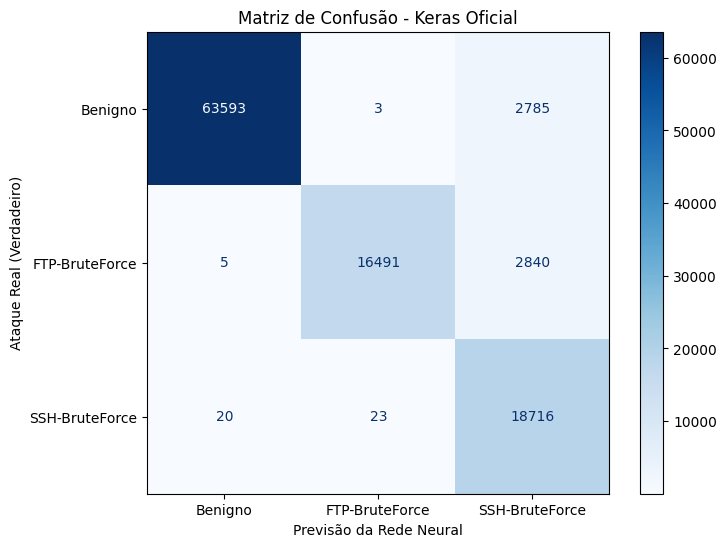

In [21]:
previsoes_probabilidades = modelo.predict(X_test)

y_previsto = np.argmax(previsoes_probabilidades, axis=1)

print("\n" + "="*50)
print("RELATÓRIO DE CLASSIFICAÇÃO")
print("="*50)

nomes_das_classes = ["Benigno", "FTP-BruteForce", "SSH-BruteForce"]

print(classification_report(y_test_encoded, y_previsto, target_names=nomes_das_classes))

print("\nGerando Matriz de Confusão Visual...")
matriz = confusion_matrix(y_test_encoded, y_previsto)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=nomes_das_classes)
disp.plot(cmap='Blues', values_format='d', ax=ax)

plt.title('Matriz de Confusão - Keras Oficial')
plt.xlabel('Previsão da Rede Neural')
plt.ylabel('Ataque Real (Verdadeiro)')
plt.show()